# Tarea 1 — Árboles de Decisión: **CHAID**


## ¿Qué es un Árbol de Decisión?

Modelo de **aprendizaje supervisado** con estructura jerárquica de nodos: cada **nodo interno** hace
una *pregunta* sobre un atributo, cada **rama** es una respuesta, y cada **hoja** es la predicción.
El entrenamiento elige en cada nodo el atributo que mejor **separa** los datos según un criterio de
pureza. Los tres algoritmos de la familia (Grupo B) se diferencian así:

| Algoritmo | Año | Autor | Criterio | División | Objetivo |
|-----------|-----|-------|----------|----------|----------|
| **ID3**   | 1986 | Quinlan | Ganancia de Información (Entropía) | Multi-vía | Categórico |
| **CART**  | 1984 | Breiman et al. | Índice Gini / MSE | Binaria | Categórico o numérico |
| **CHAID** | 1980 | Kass | Chi-cuadrado (χ²) | Multi-vía (con fusión) | Categórico |


## Ficha técnica

### Descripción
**CHAID (Chi-squared Automatic Interaction Detection)** construye árboles usando la prueba
**Chi-cuadrado (χ²)** para decidir divisiones. Permite divisiones **multi-vía** (más de dos ramas) y
**fusiona** categorías de un predictor que no son estadísticamente diferentes respecto al objetivo.
Muy usado en **marketing y segmentación** por producir árboles anchos e interpretables.

### Tipo de Modelo
- **Método de aprendizaje:** Supervisado (clasificación; variante continua con test F)
- **Por Parámetros:** No paramétrico (basado en pruebas de significancia)
- **Datos de aprendizaje:** Offline / Batch
- **Resultado del entrenamiento:** Basado en Modelo (árbol multi-vía)

### Algoritmo de Entrenamiento
Selección de divisiones mediante **prueba Chi-cuadrado** con **corrección de Bonferroni**, y
**fusión/segmentación** iterativa de categorías por valor-p:

$$\chi^{2} = \sum \frac{(O_{ij} - E_{ij})^{2}}{E_{ij}}$$

### Supuestos y Restricciones
- Variables **categóricas / nominales / ordinales** (continuas → discretizadas).
- Necesita **muestras grandes** para que χ² sea confiable.
- **No binario**: nodos con múltiples ramas → árboles anchos y poco profundos.
- Menos preciso que CART, pero **más interpretable** para segmentación.


## 1. Publicación que propuso el algoritmo
> **Kass, G. V. (1980). *An Exploratory Technique for Investigating Large Quantities of Categorical Data*. Journal of the Royal Statistical Society. Series C (Applied Statistics), 29(2), 119–127.**

Gordon V. Kass lo formalizó en 1980, sobre trabajos previos de detección de interacción (AID).

```bibtex
@article{kass1980exploratory,
  title={An exploratory technique for investigating large quantities of categorical data},
  author={Kass, Gordon V},
  journal={Journal of the Royal Statistical Society. Series C (Applied Statistics)},
  volume={29}, number={2}, pages={119--127}, year={1980}, publisher={JSTOR}
}
```
**APA:** Kass, G. V. (1980). An exploratory technique for investigating large quantities of categorical data. *Journal of the Royal Statistical Society. Series C (Applied Statistics), 29*(2), 119–127.

## 2. Cómo funciona (paso a paso)
1. Para cada predictor, **fusionar** categorías cuyas diferencias frente al objetivo **no** son significativas (mayor valor-p en χ²).
2. Calcular el χ² (con **corrección de Bonferroni**) del predictor ya fusionado.
3. Elegir el predictor con χ² **más significativo** (menor valor-p).
4. Crear una **rama por cada categoría (fusionada)** → división multi-vía.
5. **Repetir** hasta que ninguna división sea significativa o se alcance el tamaño mínimo.

## 3. Tipos de entrada
- Predictores **categóricos / nominales / ordinales**; objetivo **categórico**.
- Variables continuas → **discretizadas** en rangos.

## 4. Casos de uso
- **Segmentación de clientes** y estudios de mercado (uso más común).
- Análisis de **encuestas** y datos demográficos.
- Detección exploratoria de **interacciones** entre variables categóricas.

## 5. Source Code en Python
Librería **`CHAID`** sobre el dataset **Titanic** (variables categóricas → supervivencia).


In [ ]:
# CHAID no viene preinstalado en Colab
!pip install CHAID -q

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, seaborn as sns

# ------- Datos categóricos (Titanic) -------
titanic = sns.load_dataset("titanic")
cols = ["sex", "class", "embark_town", "alone", "survived"]
df_chaid = titanic[cols].dropna().copy()
df_chaid["survived"] = df_chaid["survived"].map({0: "No", 1: "Si"})
df_chaid["alone"]    = df_chaid["alone"].map({True: "Solo", False: "Acompanado"})
df_chaid = df_chaid.astype(str)

print("Forma:", df_chaid.shape)
df_chaid.head()


Forma: (889, 5)


,sex,class,embark_town,alone,survived
0,male,Third,Southampton,Acompanado,No
1,female,First,Cherbourg,Acompanado,Si
2,female,Third,Southampton,Solo,Si
3,female,First,Southampton,Acompanado,Si
4,male,Third,Southampton,Solo,No


In [ ]:
# ------- Construcción del árbol CHAID -------
from CHAID import Tree

independientes = ["sex", "class", "embark_town", "alone"]
tipos = {col: "nominal" for col in independientes}

tree_chaid = Tree.from_pandas_df(
    df_chaid, i_variables=tipos, d_variable="survived",
    max_depth=3, min_child_node_size=30, alpha_merge=0.05)

# Cada nodo muestra el predictor elegido, el chi2 y el p-valor
tree_chaid.print_tree()


([], {'No': 549.0, 'Si': 340.0}, (sex, p=1.1739578304122022e-58, score=260.7563422490309, groups=[['female'], ['male']]), dof=1))
|-- (['female'], {'No': 81.0, 'Si': 231.0}, (class, p=3.0644669207819066e-19, score=80.39579468150896, groups=[['First', 'Second'], ['Third']]), dof=1))
|   |-- (['First', 'Second'], {'No': 9.0, 'Si': 159.0}, <Invalid Chaid Split> - p-value greater than alpha merge)
|   +-- (['Third'], {'No': 72.0, 'Si': 72.0}, (embark_town, p=0.0001694392021937066, score=14.142857142857142, groups=[['Cherbourg', 'Queenstown'], ['Southampton']]), dof=1))
|       |-- (['Cherbourg', 'Queenstown'], {'No': 17.0, 'Si': 39.0}, <Invalid Chaid Split> - the max depth has been reached)
|       +-- (['Southampton'], {'No': 55.0, 'Si': 33.0}, <Invalid Chaid Split> - the max depth has been reached)
+-- (['male'], {'No': 468.0, 'Si': 109.0}, (class, p=1.0782074273318612e-08, score=32.69488212267723, groups=[['First'], ['Second', 'Third']]), dof=1))
    |-- (['First'], {'No': 77.0, 'Si': 4

In [ ]:
# ------- Resumen del árbol CHAID -------
print("Nodos del árbol CHAID:\n")
for node in tree_chaid:
    print(node)
print("\nRiesgo (error de clasificación):", tree_chaid.risk())


Nodos del árbol CHAID:

([], {'No': 549.0, 'Si': 340.0}, (sex, p=1.1739578304122022e-58, score=260.7563422490309, groups=[['female'], ['male']]), dof=1))
(['female'], {'No': 81.0, 'Si': 231.0}, (class, p=3.0644669207819066e-19, score=80.39579468150896, groups=[['First', 'Second'], ['Third']]), dof=1))
(['First', 'Second'], {'No': 9.0, 'Si': 159.0}, <Invalid Chaid Split> - p-value greater than alpha merge)
(['Third'], {'No': 72.0, 'Si': 72.0}, (embark_town, p=0.0001694392021937066, score=14.142857142857142, groups=[['Cherbourg', 'Queenstown'], ['Southampton']]), dof=1))
(['Cherbourg', 'Queenstown'], {'No': 17.0, 'Si': 39.0}, <Invalid Chaid Split> - the max depth has been reached)
(['Southampton'], {'No': 55.0, 'Si': 33.0}, <Invalid Chaid Split> - the max depth has been reached)
(['male'], {'No': 468.0, 'Si': 109.0}, (class, p=1.0782074273318612e-08, score=32.69488212267723, groups=[['First'], ['Second', 'Third']]), dof=1))
(['First'], {'No': 77.0, 'Si': 45.0}, <Invalid Chaid Split> - p-

## 6. Evaluación del modelo
Además del riesgo interno, medimos el modelo con *accuracy*, *precision/recall/F1* por clase y una matriz de confusión.

Accuracy (in-sample): 0.811

              precision    recall  f1-score   support

          No       0.79      0.95      0.86       549
          Si       0.88      0.58      0.70       340

    accuracy                           0.81       889
   macro avg       0.84      0.77      0.78       889
weighted avg       0.82      0.81      0.80       889



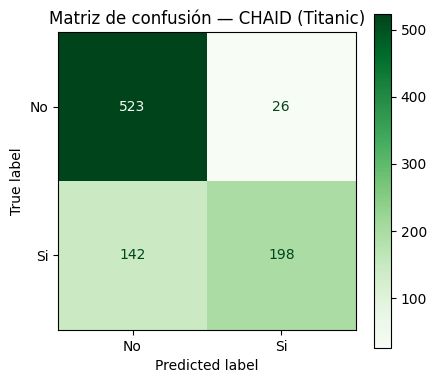

In [ ]:
# ------- Evaluación del modelo -------
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# model_predictions(): clase predicha (mayoría de la hoja) para cada fila
y_true = df_chaid["survived"].to_numpy()
y_pred = np.asarray(tree_chaid.model_predictions()).astype(str)

print(f"Accuracy (in-sample): {accuracy_score(y_true, y_pred):.3f}\n")
print(classification_report(y_true, y_pred))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, labels=["No", "Si"], cmap="Greens", ax=ax)
ax.set_title("Matriz de confusión — CHAID (Titanic)")
plt.tight_layout(); plt.show()

## 7. Interpretación gráfica
Tasa de supervivencia según los predictores que encabezan el árbol (`sex`, `class`): explica *por qué* CHAID los selecciona primero.

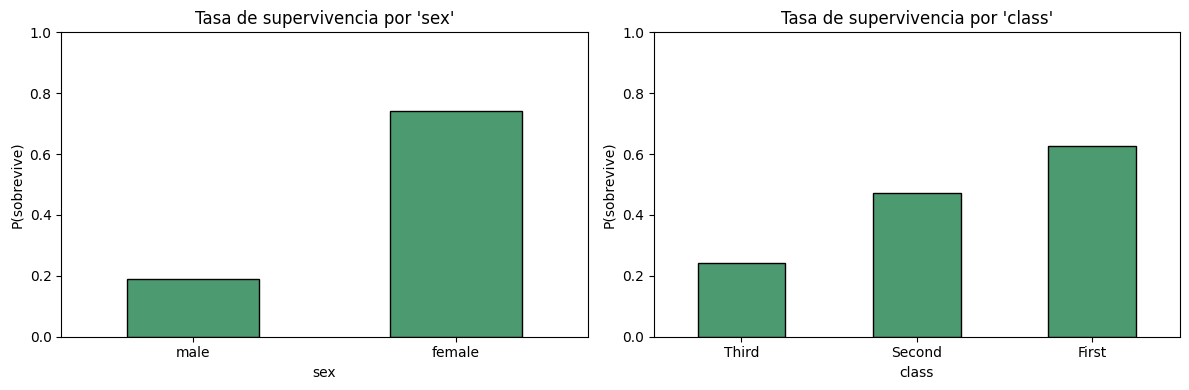

In [ ]:
# ------- Interpretación gráfica: tasa de supervivencia por predictor -------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["sex", "class"]):
    tasa = (df_chaid.assign(surv=(df_chaid["survived"] == "Si").astype(int))
                    .groupby(col)["surv"].mean().sort_values())
    tasa.plot(kind="bar", ax=ax, color="#4C9A70", edgecolor="black")
    ax.set_title(f"Tasa de supervivencia por '{col}'")
    ax.set_ylabel("P(sobrevive)"); ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## Conclusión
- Sobre **Titanic (datos reales categóricos)**, CHAID elige como primera división el predictor **`sex`** (χ² más significativo), coherente con el patrón histórico *"mujeres y niños primero"*.
- Al ser **multi-vía y con fusión de categorías**, produce un árbol **ancho y muy interpretable**, ideal para *segmentación* (marketing, encuestas, demografía).
- El *accuracy* y la **matriz de confusión** muestran un desempeño razonable usando solo 4 variables nominales; CHAID prioriza la **interpretabilidad** sobre la exactitud (suele ser menos preciso que CART).
- Los **gráficos de tasa de supervivencia** por `sex` y `class` explican visualmente *por qué* esas variables encabezan el árbol.

## Referencia
Kass, G. V. (1980). An exploratory technique for investigating large quantities of categorical data. *Journal of the Royal Statistical Society. Series C (Applied Statistics), 29*(2), 119–127.
